In [1]:
import pandas as pd

In [2]:
# Load both sheets
df1 = pd.read_excel("online_retail_II.xlsx", sheet_name="Year 2009-2010")
df2 = pd.read_excel("online_retail_II.xlsx", sheet_name="Year 2010-2011")

In [3]:
# Combine both datasets
df = pd.concat([df1, df2], ignore_index=True)

In [4]:
# Check shape
print("Combined Shape:", df.shape)

Combined Shape: (1067371, 8)


In [5]:
# Rename columns for consistency
df.rename(columns={"Customer ID": "CustomerID","Price": "UnitPrice"}, inplace=True)

In [6]:
# Drop missing values
df = df.dropna(subset=["CustomerID", "Description"])

In [7]:
# Remove returns (negative quantity)
df = df[df["Quantity"] > 0]

In [8]:
# Convert date column
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [9]:
# Create TotalPrice column
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [10]:
# Remove duplicates
df = df.drop_duplicates()

In [11]:
# Final check
print("Cleaned Shape:", df.shape)
df.head()

Cleaned Shape: (779495, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [12]:
# Reference date (latest date in dataset)
reference_date = df["InvoiceDate"].max()

In [13]:
# Create RFM table
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,  # Recency
    "Invoice": "nunique",  # Frequency (number of invoices)
    "TotalPrice": "sum"  # Monetary
})

In [14]:
# Rename columns
rfm.columns = ["Recency", "Frequency", "Monetary"]

# Reset index
rfm = rfm.reset_index()

In [15]:
# View result
print(rfm.head())
print("Total Customers:", rfm.shape[0])

   CustomerID  Recency  Frequency  Monetary
0     12346.0      325         12  77556.46
1     12347.0        1          8   4921.53
2     12348.0       74          5   2019.40
3     12349.0       18          4   4428.69
4     12350.0      309          1    334.40
Total Customers: 5881


In [19]:
# Add AvgOrderValue
rfm["AvgOrderValue"] = rfm["Monetary"] / rfm["Frequency"]

# Check
rfm.head()

,CustomerID,Recency,Frequency,Monetary,AvgOrderValue
0,12346.0,325,12,77556.46,6463.038333
1,12347.0,1,8,4921.53,615.191250
2,12348.0,74,5,2019.40,403.880000
3,12349.0,18,4,4428.69,1107.172500
4,12350.0,309,1,334.40,334.400000


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [20]:
# Features and target
X = rfm[["Recency", "Frequency", "AvgOrderValue"]]
y = rfm["Monetary"]

In [21]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
# Model
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Predictions
y_pred = model_lr.predict(X_test)

In [23]:
# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

Linear Regression Results:
MAE: 1868.4787266402923
RMSE: 14432.0425254146
R2 Score: 0.3459542802897858


In [24]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results:")
print("MAE:", mae_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)
print("-"*40)

Decision Tree Results:
MAE: 190.03744095157182
RMSE: 1689.1209356947827
R2 Score: 0.991040701680089
----------------------------------------


In [25]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results:")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)
print("-"*40)

Random Forest Results:
MAE: 283.0521477315206
RMSE: 6351.348599446648
R2 Score: 0.8733268973157559
----------------------------------------


In [26]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Results:")
print("MAE:", mae_gb)
print("RMSE:", rmse_gb)
print("R2 Score:", r2_gb)
print("-"*40)

Gradient Boosting Results:
MAE: 340.0938234384018
RMSE: 2181.7143957177523
R2 Score: 0.9850531972728208
----------------------------------------


In [27]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svr_model = SVR()
svr_model.fit(X_train_scaled, y_train)

y_pred_svr = svr_model.predict(X_test_scaled)

mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr)

print("SVR Results:")
print("MAE:", mae_svr)
print("RMSE:", rmse_svr)
print("R2 Score:", r2_svr)
print("-"*40)

SVR Results:
MAE: 2342.0716073689523
RMSE: 17920.83741802074
R2 Score: -0.008484221467655706
----------------------------------------


In [28]:
results = pd.DataFrame({
    "Model": ["Linear", "Decision Tree", "Random Forest", "Gradient Boosting", "SVR"],
    "MAE": [mae, mae_dt, mae_rf, mae_gb, mae_svr],
    "RMSE": [rmse, rmse_dt, rmse_rf, rmse_gb, rmse_svr],
    "R2": [r2, r2_dt, r2_rf, r2_gb, r2_svr]
})

print(results.sort_values(by="RMSE"))

               Model          MAE          RMSE        R2
1      Decision Tree   190.037441   1689.120936  0.991041
3  Gradient Boosting   340.093823   2181.714396  0.985053
2      Random Forest   283.052148   6351.348599  0.873327
0             Linear  1868.478727  14432.042525  0.345954
4                SVR  2342.071607  17920.837418 -0.008484


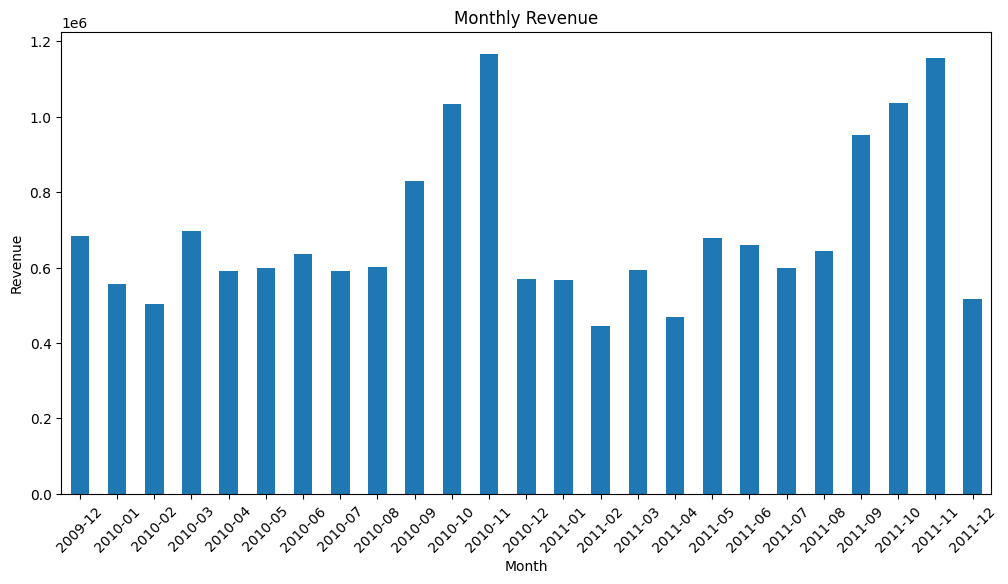

In [29]:
# Extract month
df["Month"] = df["InvoiceDate"].dt.to_period("M")

# Group by month
monthly_revenue = df.groupby("Month")["TotalPrice"].sum()

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
monthly_revenue.plot(kind="bar")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

In [31]:
def categorize_product(desc):
    desc = str(desc).lower()
    
    if "food" in desc or "cake" in desc or "tea" in desc:
        return "Food"
    elif "light" in desc or "lamp" in desc or "bulb" in desc:
        return "Electronics"
    elif "plate" in desc or "bowl" in desc or "kitchen" in desc or "spoon" in desc:
        return "Utensils"
    elif "bag" in desc or "box" in desc or "gift" in desc:
        return "Accessories"
    else:
        return "Others"

# Apply function
df["Category"] = df["Description"].apply(categorize_product)

# Check
df["Category"].value_counts()

Category
Others         533295
Accessories    115832
Food            70125
Electronics     38373
Utensils        21870
Name: count, dtype: int64

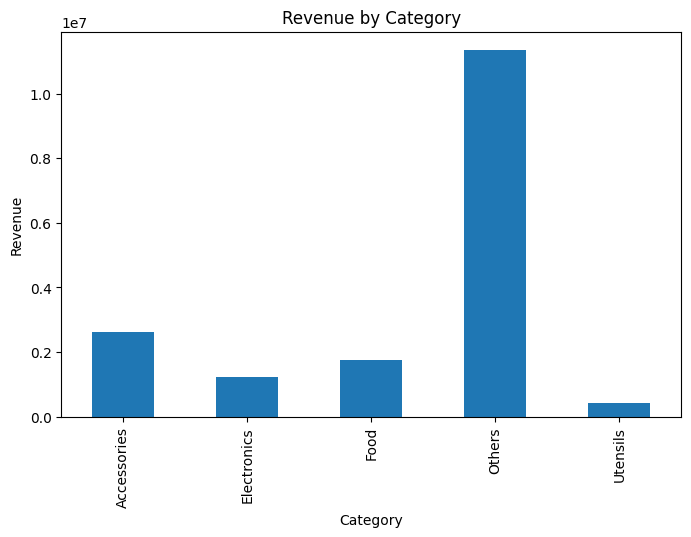

In [32]:
category_revenue = df.groupby("Category")["TotalPrice"].sum()

plt.figure(figsize=(8,5))
category_revenue.plot(kind="bar")
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

In [33]:
# Extract month
df["Month"] = df["InvoiceDate"].dt.to_period("M")

# Group by month and category
monthly_qty = df.groupby(["Month", "Category"])["Quantity"].sum().reset_index()

print(monthly_qty.head())

     Month     Category  Quantity
0  2009-12  Accessories     52406
1  2009-12  Electronics     32193
2  2009-12         Food     38146
3  2009-12       Others    268322
4  2009-12     Utensils      7641


In [34]:
# Select one category
food_data = monthly_qty[monthly_qty["Category"] == "Food"].copy()

# Convert Month to numeric index
food_data["MonthIndex"] = range(len(food_data))

# Features and target
X_food = food_data[["MonthIndex"]]
y_food = food_data["Quantity"]

# Train model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_food, y_food)

# Predict next month
next_month = [[len(food_data)]]
prediction = model.predict(next_month)

print("Next Month Food Demand Prediction:", prediction[0])

Next Month Food Demand Prediction: 34046.59


e:\Softwares\anaconda3\envs\kagglee\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


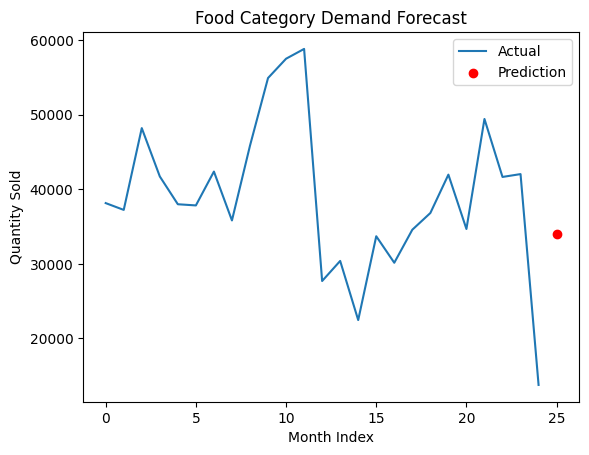

In [35]:
import matplotlib.pyplot as plt

plt.plot(food_data["MonthIndex"], y_food, label="Actual")
plt.scatter(len(food_data), prediction, color='red', label="Prediction")
plt.title("Food Category Demand Forecast")
plt.xlabel("Month Index")
plt.ylabel("Quantity Sold")
plt.legend()
plt.show()

In [36]:
# Train individual models

lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42)
gb = GradientBoostingRegressor(random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [37]:
# Predictions
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_gb = gb.predict(X_test)

In [38]:
# Hybrid (weighted average)
y_pred_hybrid = (0.2 * y_pred_lr + 0.3 * y_pred_rf + 0.5 * y_pred_gb)

In [39]:
# Evaluation
mae_h = mean_absolute_error(y_test, y_pred_hybrid)
rmse_h = np.sqrt(mean_squared_error(y_test, y_pred_hybrid))
r2_h = r2_score(y_test, y_pred_hybrid)

print("Hybrid Model Results:")
print("MAE:", mae_h)
print("RMSE:", rmse_h)
print("R2 Score:", r2_h)

Hybrid Model Results:
MAE: 547.787914730035
RMSE: 5820.496884692087
R2 Score: 0.8936169027414869


In [ ]:
import gradio as gr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# -------- MAIN FUNCTION -------- #

def process_file(file):

    # Load file
    df = pd.read_excel(file.name)

    # --- CLEANING ---
    df.rename(columns={"Customer ID": "CustomerID", "Price": "UnitPrice"}, inplace=True)
    df = df.dropna(subset=["CustomerID", "Description"])
    df = df[df["Quantity"] > 0]
    df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
    df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]
    df = df.drop_duplicates()

    # --- CATEGORY ---
    def categorize(desc):
        desc = str(desc).lower()
        if "food" in desc or "cake" in desc:
            return "Food"
        elif "light" in desc or "lamp" in desc:
            return "Electronics"
        elif "plate" in desc or "bowl" in desc:
            return "Utensils"
        elif "bag" in desc or "box" in desc:
            return "Accessories"
        else:
            return "Others"

    df["Category"] = df["Description"].apply(categorize)

    # --- RFM ---
    ref_date = df["InvoiceDate"].max()

    rfm = df.groupby("CustomerID").agg({
        "InvoiceDate": lambda x: (ref_date - x.max()).days,
        "Invoice": "nunique",
        "TotalPrice": "sum"
    })

    rfm.columns = ["Recency", "Frequency", "Monetary"]
    rfm["AvgOrderValue"] = rfm["Monetary"] / rfm["Frequency"].replace(0,1)
    rfm = rfm.reset_index()

    # --- MODEL ---
    X = rfm[["Recency", "Frequency", "AvgOrderValue"]]
    y = rfm["Monetary"]

    model = GradientBoostingRegressor()
    model.fit(X, y)

    rfm["Predicted_CLV"] = model.predict(X)

    # --- TOP CUSTOMERS ---
    top_customers = rfm.sort_values(by="Predicted_CLV", ascending=False).head(5)

    # --- MONTHLY REVENUE GRAPH ---
    df["Month"] = df["InvoiceDate"].dt.to_period("M")
    monthly_rev = df.groupby("Month")["TotalPrice"].sum()

    plt.figure()
    monthly_rev.plot(kind="bar")
    plt.title("Monthly Revenue")
    plt.xticks(rotation=45)
    plt.tight_layout()
    monthly_path = "monthly.png"
    plt.savefig(monthly_path)
    plt.close()

    # --- CATEGORY GRAPH ---
    cat_rev = df.groupby("Category")["TotalPrice"].sum()

    plt.figure()
    cat_rev.plot(kind="bar")
    plt.title("Category Revenue")
    plt.tight_layout()
    cat_path = "category.png"
    plt.savefig(cat_path)
    plt.close()

    # --- FORECAST (Food) ---
    monthly_qty = df.groupby(["Month", "Category"])["Quantity"].sum().reset_index()
    food = monthly_qty[monthly_qty["Category"] == "Food"].copy()

    if len(food) > 2:
        food["idx"] = range(len(food))
        Xf = food[["idx"]]
        yf = food["Quantity"]

        f_model = LinearRegression()
        f_model.fit(Xf, yf)

        pred = f_model.predict([[len(food)]])[0]
    else:
        pred = 0

    # --- SUMMARY TEXT ---
    summary = f"""
    📊 Dataset processed successfully!

    👥 Total Customers: {rfm.shape[0]}
    💰 Average CLV: {rfm["Predicted_CLV"].mean():.2f}
    🔝 Top Customer CLV: {rfm["Predicted_CLV"].max():.2f}

    📦 Next Month Food Demand: {int(pred)}
    """

    return summary, monthly_path, cat_path, top_customers


# -------- UI -------- #

interface = gr.Interface(
    fn=process_file,
    inputs=gr.File(label="Upload Retail Dataset"),
    outputs=[
        gr.Textbox(label="Summary"),
        gr.Image(label="Monthly Revenue"),
        gr.Image(label="Category Revenue"),
        gr.Dataframe(label="Top Customers")
    ],
    title="Financial Analysis & CLV Prediction System",
    description="Upload your dataset to get financial insights, CLV prediction, and forecasting"
)

interface.launch(share=True)

e:\Softwares\anaconda3\envs\kagglee\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://159ea36b16f9dd8e76.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Traceback (most recent call last):
  File "e:\Softwares\anaconda3\envs\kagglee\Lib\site-packages\gradio\queueing.py", line 766, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\Softwares\anaconda3\envs\kagglee\Lib\site-packages\gradio\route_utils.py", line 355, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\Softwares\anaconda3\envs\kagglee\Lib\site-packages\gradio\blocks.py", line 2157, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\Softwares\anaconda3\envs\kagglee\Lib\site-packages\gradio\blocks.py", line 1634, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\Softwares\anaconda3\envs\kagglee\Lib\site-packages\anyio\to_thread.py", line 63, in run_sync
    return